## NB1 

# Phase 1: Exploratory Data Analysis (EDA) - Financial AML
**Objective:** Understand the distribution of transactions and identify behavioral patterns that distinguish fraudulent activity from legitimate transfers.

steps
1. Import the libraries
2. Quick data check up
3. Data cleaning
4. EDA
5. Save the new data set

## 1. Import the libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# layout
plt.style.use('fivethirtyeight')
colors = ["#2C3E50", "#E74C3C", "#ECF0F1"]
sns.set_palette(sns.color_palette(colors))

print("Environment Ready")

Environment Ready


## 2. Quick Data Checkup


In [6]:
# Load the raw data
raw_data_path = "C:/Projects/11_Financial_AML/data/PS_20174392719_1491204439457_log.csv"
df = pd.read_csv(raw_data_path)

# Dimensionality and Types
print(f"Dataset Shape: {df.shape}")
display(df.head())
display(df.info())

# Missing Value Audit
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


None


Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
# Filtering the noise
at_risk_types = ['TRANSFER', 'CASH_OUT']
df_cleaned = df[df['type'].isin(at_risk_types)].copy()

# Remove unnecessary columns that won't be used in EDA or Modeling
# We keep nameOrig/Dest for now just for EDA, will drop in NB2
df_cleaned.drop(['isFlaggedFraud'], axis=1, inplace=True)

print(f"Data pruned. Remaining rows: {len(df_cleaned)}")

Data pruned. Remaining rows: 2770409


## 4. Exploratory data analysis
### Visualizing the Imbalance
Money laundering is a 'needle in a haystack' problem. Let's visualize the target distribution.

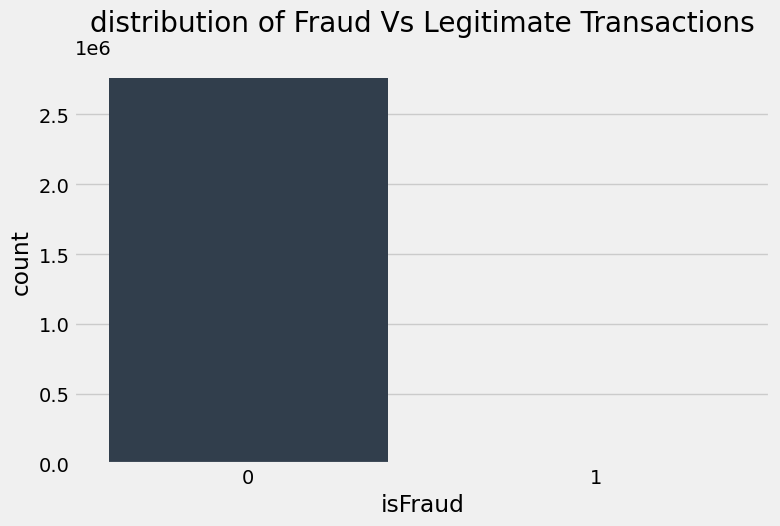

In [11]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x="isFraud", data=df_cleaned)
plt.title("distribution of Fraud Vs Legitimate Transactions")
plt.show()

## 5. Save the new dataset

In [12]:
df_cleaned.to_csv('C:/Projects/11_Financial_AML/data/aml_cleaned.csv', index=False)
print("SUCCESS: aml_cleaned.csv saved.")

SUCCESS: aml_cleaned.csv saved.
